In [237]:
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree, DecisionTreeRegressor


In [238]:
data = pd.read_csv('Data_with actual dates/pone.0300127.s001.csv')
demographic_data = pd.read_csv('Data_with actual dates/Demographics_09Oct2025.csv')
family_history = pd.read_csv('Data_with actual dates/Family_History_09Oct2025.csv')

In [239]:
data.head()

,PATNO,COHORT,COHORT_DEFINITION,ENROLL_DATE,ENROLL_STATUS,STATUS_DATE,SCREENEDAM,ENROLL_AGE,INEXPAGE,AV133STDY,TAUSTDY,GAITSTDY,PISTDY,SV2ASTDY,NXTAUSTDY,DATELIG,PPMI_ONLINE_ENROLL,ENRLPINK1,ENRLPRKN,ENRLSRDC,ENRLNORM,ENRLOTHGV,ENRLHPSM,ENRLRBD,ENRLLRRK2,ENRLSNCA,ENRLGBA
0,3000,2,Healthy Control,02/2011,Withdrew,10/2024,NaN,69.1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0
1,3001,1,Parkinson's Disease,03/2011,Enrolled,09/2021,NaN,65.1,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
2,3002,1,Parkinson's Disease,03/2011,Withdrew,10/2024,NaN,67.6,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NO,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
3,3003,1,Parkinson's Disease,04/2011,Enrolled,01/2022,NaN,56.7,NaN,0.0,0.0,0.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,1.0,NaN,NaN,0,0,0,0,0
4,3004,2,Healthy Control,04/2011,Enrolled,01/2022,NaN,59.4,NaN,0.0,0.0,1.0,0.0,0.0,0.0,NaN,YES,0.0,0.0,0.0,NaN,NaN,0,0,0,0,0


In [240]:
df1=data[data['COHORT']==1]

In [241]:
df2=df1[(df1['ENROLL_STATUS']=='Enrolled') | (df1['ENROLL_STATUS']=='Complete') | (df1['ENROLL_STATUS']=='Withdraw Deceased')]

In [242]:
patient_data = df2[['PATNO','COHORT_DEFINITION','ENROLL_STATUS']]


In [243]:
demographic_data.head()

,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,AFICBERB,ASHKJEW,BASQUE,BIRTHDT,SEX,CHLDBEAR,HOWLIVE,GAYLES,HETERO,BISEXUAL,PANSEXUAL,ASEXUAL,OTHSEXUALITY,HANDED,HISPLAT,RAASIAN,RABLACK,RAHAWOPI,RAINDALS,RANOS,RAWHITE,RAUNKNOWN,ORIG_ENTRY,LAST_UPDATE
0,IA86904,3000,TRANS,SCREEN,01/2011,0.0,0.0,0.0,12/1941,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,01/2011,2022-11-07 00:00:00.0
1,IA86905,3001,TRANS,SCREEN,02/2011,0.0,0.0,0.0,01/1946,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,02/2011,2022-11-07 00:00:00.0
2,IA86906,3002,TRANS,SCREEN,03/2011,0.0,0.0,0.0,08/1943,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0
3,IA86907,3003,TRANS,SCREEN,03/2011,0.0,0.0,0.0,07/1954,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0
4,IA86908,3004,TRANS,SCREEN,03/2011,0.0,0.0,0.0,11/1951,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,03/2011,2022-11-07 00:00:00.0


In [244]:
import pandas as pd
import numpy as np


merged = patient_data.merge(demographic_data, on='PATNO', how='left')

race_cols = ['RAASIAN','RABLACK','RAHAWOPI','RAINDALS','RANOS','RAWHITE','RAUNKNOWN']
race_map = {
    'RAASIAN':   'Asian',
    'RABLACK':   'Black or African American',
    'RAHAWOPI':  'Native Hawaiian or Other Pacific Islander',
    'RAINDALS':  'American Indian or Alaska Native',
    'RANOS':     'Not Otherwise Specified',
    'RAWHITE':   'White',
    'RAUNKNOWN': 'Unknown'
}

def infer_race(row):
    flags = {col: (1 if pd.notna(row.get(col)) and float(row[col]) == 1.0 else 0) for col in race_cols}
    on_cols = [race_map[c] for c, v in flags.items() if v == 1]
    if len(on_cols) == 0:
        return 'Unknown'
    if len(on_cols) == 1:
        return on_cols[0]
    return 'Multiple'

merged['RACE'] = merged.apply(infer_race, axis=1)

Demo_df = merged[['PATNO', 'BIRTHDT', 'RACE', 'SEX']].reset_index(drop=True)
Demo_df.head()


,PATNO,BIRTHDT,RACE,SEX
0,3001,01/1946,White,1.0
1,3003,07/1954,White,0.0
2,3010,06/1964,White,1.0
3,3012,01/1953,White,1.0
4,3018,09/1951,White,0.0


In [245]:

anyfam_bin = (
    family_history['ANYFAMPD']
      .fillna(0)
      .gt(0)
      .astype(int)
)

anyfam_by_pat = (
    family_history.assign(ANYFAMPD_bin=anyfam_bin)
      .groupby('PATNO',as_index=False)['ANYFAMPD_bin']
      .max()
      .rename(columns={'ANYFAMPD_bin':'FamilyHistory'})
)

anyfam_by_pat.head(10)
data1 = Demo_df.merge(anyfam_by_pat, on='PATNO', how='left')
data1.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory
0,3001,01/1946,White,1.0,0.0
1,3003,07/1954,White,0.0,0.0
2,3010,06/1964,White,1.0,1.0
3,3012,01/1953,White,1.0,0.0
4,3018,09/1951,White,0.0,1.0


In [246]:
pd_diagnosis_history = pd.read_csv('Data_with actual dates/PD_Diagnosis_History_22Oct2025.csv')

In [247]:
diagnosis=pd_diagnosis_history[['PATNO','PDDXDT','DXTREMOR','DXRIGID','DXBRADY','DXOTHSX','DOMSIDE']]
diagnosis.head()

,PATNO,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE
0,3001,04/2010,1.0,1.0,1.0,0.0,2.0
1,3002,02/2010,1.0,0.0,1.0,1.0,1.0
2,3003,03/2009,0.0,1.0,1.0,1.0,2.0
3,3005,NaN,NaN,NaN,NaN,NaN,NaN
4,3006,11/2010,1.0,1.0,1.0,0.0,2.0


In [248]:
data2=data1.merge(diagnosis, on ='PATNO', how = 'left')
data2.shape

(1173, 11)

In [249]:
dopamine_theraphy_data = pd.read_csv('Data_with actual dates/Initiation_of_Dopaminergic_Therapy_22Oct2025.csv')
dopamine_flag = (
    dopamine_theraphy_data.groupby('PATNO', as_index=False)['DOPTHERST']
    .max()
)
data3= data2.merge(dopamine_flag, on ='PATNO',how ='left')
data3.shape

(1173, 12)

In [250]:
montreal_cognitive_Ass = pd.read_csv('Data_with actual dates/Montreal_Cognitive_Assessment__MoCA__22Oct2025.csv')
montreal_cognitive_Ass['INFODT_parsed'] = pd.to_datetime(montreal_cognitive_Ass['INFODT'], format='%m/%Y', errors='coerce')
# mcascore = (
#     montreal_cognitive_Ass.sort_values(['PATNO', 'INFODT_parsed'])
#     .groupby('PATNO', as_index=False)
#     .tail(1)
# )

tmp = (
    montreal_cognitive_Ass
      .sort_values(['PATNO', 'INFODT_parsed'], ascending=[True, True])
      .assign(MCATOT_latest=lambda d: d.groupby('PATNO')['MCATOT'].ffill())
)

mcascore = (
    tmp.groupby('PATNO', as_index=False)
       .tail(1)[['PATNO', 'MCATOT_latest']]
       .rename(columns={'MCATOT_latest': 'MCATOT'})
)

data4 = data3.merge(mcascore, on='PATNO', how='left')
data4 = data3.merge(mcascore[['PATNO','MCATOT']], on ='PATNO', how='left')
data4.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0


In [251]:
freezing_fall = pd.read_csv('Data_with actual dates/Determination_of_Freezing_and_Falls_22Oct2025.csv')
freezing_fall['INFODT_parsed'] = pd.to_datetime(freezing_fall['INFODT'], format='%m/%Y', errors='coerce')

# latest_rows = (
#     freezing_fall
#     .sort_values(['PATNO', 'INFODT_parsed'])
#     .groupby('PATNO', as_index=False)
#     .tail(1)
# )
# latest_frz = latest_rows[['PATNO', 'FRZGT12M','FLNFR12M']].reset_index(drop=True)
# other_cols = [
#     'INJFRHIP','INJFRUE','INJFRSKL','INJFROTH',
#     'HINJNOLC','HINJLOC2','INJSTCH','INJOTH',
#     'FLLDRVIS','FLLERVIS','FLLHOSP','FLLSURG','FLLINST'
# ]

# agg_other = (
#     freezing_fall
#     .fillna(0)
#     .groupby('PATNO', as_index=False)[other_cols]
#     .max()
# )

# freeze_combined = latest_frz.merge(agg_other, on='PATNO', how='outer')
# data5 = data4.merge(freeze_combined, on='PATNO', how='left')
# print(data5.shape)



In [252]:
import pandas as pd

try:
    df = freezing_fall.copy()
except NameError:
    _ff_path = 'Data_with actual dates/Determination_of_Freezing_and_Falls_22Oct2025.csv'
    freezing_fall = pd.read_csv(_ff_path)
    freezing_fall['INFODT_parsed'] = pd.to_datetime(
        freezing_fall['INFODT'], format='%m/%Y', errors='coerce'
    )
    df = freezing_fall.copy()

if 'data4' not in globals():
    raise RuntimeError(
        'data4 is not defined — run upstream cells through the MoCA merge (builds data4) before this cell.'
    )

def pick_row_for_patient(patient_df):
    # sort once so "latest" is easy
    patient_df = patient_df.sort_values('INFODT_parsed')

    # 1. Most recent date for this patient
    latest_date = patient_df['INFODT_parsed'].max()
    latest_year = latest_date.year

    # 2. Which years does this patient have data for?
    years_present = set(patient_df['INFODT_parsed'].dt.year.dropna())

    # 3. Check continuous 3-year coverage: Y, Y-1, Y-2
    required_years = {latest_year, latest_year - 1, latest_year - 2}
    has_continuous_3yr = required_years.issubset(years_present)

    if has_continuous_3yr:
        # Keep only rows from those 3 required years
        recent_window = patient_df[
            patient_df['INFODT_parsed'].dt.year.isin(required_years)
        ]

        # Pick row with highest FRZGT12M, break ties by most recent date
        best_row = (
            recent_window
            .sort_values(
                by=['FLNFR12M', 'INFODT_parsed'],
                ascending=[False, False]
            )
            .iloc[0]
        )
    else:
        # Fall back to just the single latest row overall
        best_row = (
            patient_df
            .sort_values('INFODT_parsed', ascending=False)
            .iloc[0]
        )

    return best_row

# Apply per patient (avoid groupby.apply: pandas 2.2+ may drop PATNO from chunks → KeyError)
best_rows = pd.DataFrame(
    [pick_row_for_patient(g) for _, g in df.fillna(0).groupby('PATNO')]
).reset_index(drop=True)
best_rows=best_rows[['PATNO', 'FRZGT12M','FLNFR12M',
    'INJFRHIP','INJFRUE','INJFRSKL','INJFROTH',
    'HINJNOLC','HINJLOC2','INJSTCH','INJOTH',
    'FLLDRVIS','FLLERVIS','FLLHOSP','FLLSURG','FLLINST','INFODT_parsed']]
data5 = data4.merge(best_rows, on ='PATNO', how='left')
data5.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01


In [253]:
scopa = pd.read_csv('Data_with actual dates/SCOPA-AUT_22Oct2025.csv')
scopa['INFODT_parsed'] = pd.to_datetime(scopa['INFODT'], format='%m/%Y', errors='coerce')

scopa_aut = (
    scopa.sort_values(['PATNO', 'INFODT_parsed'])
      .groupby('PATNO', as_index=False)
      .tail(1)
)
scopa_latest=scopa_aut[['PATNO','SCAU14','SCAU16']].reset_index(drop=True)
data6=data5.merge(scopa_latest, on='PATNO', how='left')
data6.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0


In [254]:
neuro_QoL=pd.read_csv('Data_with actual dates/Neuro_QoL__Lower_Extremity_Function__Mobility__-_Short_Form_22Oct2025.csv')


neuro_QoL['INFODT_parsed'] = pd.to_datetime(neuro_QoL['INFODT'], format='%m/%Y', errors='coerce')

latest_rows = (
    neuro_QoL.sort_values(['PATNO', 'INFODT_parsed'])
      .groupby('PATNO', as_index=False)
      .tail(1)
)
nqmob37_latest = latest_rows[['PATNO', 'NQMOB37','NQMOB30','NQMOB26','NQMOB32','NQMOB33','NQMOB31','NQMOB28']].reset_index(drop=True)
data7=data6.merge(nqmob37_latest, on ='PATNO', how='left')
data7.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0


In [255]:
geriatric_depression = pd.read_csv('Data_with actual dates/Geriatric_Depression_Scale__Short_Version__22Oct2025.csv')
flip_cols = ['GDSSATIS', 'GDSGSPIR', 'GDSHAPPY', 'GDSALIVE', 'GDSENRGY']

for c in flip_cols:
    geriatric_depression[c] = geriatric_depression[c].where(geriatric_depression[c].isna(), 1 - geriatric_depression[c].astype(float))

sum_cols = [
    'GDSSATIS','GDSDROPD','GDSEMPTY','GDSBORED','GDSGSPIR','GDSAFRAD',
    'GDSHAPPY','GDSHLPLS','GDSHOME','GDSMEMRY','GDSALIVE','GDSWRTLS',
    'GDSENRGY','GDSHOPLS','GDSBETER'
]

geriatric_depression['Total Depression Score'] = geriatric_depression[sum_cols].sum(axis=1, skipna=True).astype(float)
geriatric_depressionScore = (
    geriatric_depression.groupby('PATNO', as_index=False)['Total Depression Score']
    .max()
)
# geriatric_depression = geriatric_depression[geriatric_depression['EVENT_ID']=='BL']
scale_score = ['PATNO', 'Total Depression Score']
data8=data7.merge(geriatric_depressionScore[scale_score], on ='PATNO', how='left')
data8.head(5)

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0


In [256]:
data8.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0


In [257]:
MDS_UPDRS=pd.read_csv('Data_with actual dates/MDS-UPDRS_Part_IV__Motor_Complications_22Oct2025.csv')


MDS_UPDRS['INFODT_parsed'] = pd.to_datetime(MDS_UPDRS['INFODT'], format='%m/%Y', errors='coerce')

latest_rows_updrs = (
    MDS_UPDRS.groupby('PATNO', as_index=False)['NP4TOT']
    .max()
)
MDS_UPDRS_latest = latest_rows_updrs[['PATNO', 'NP4TOT']].reset_index(drop=True)
data9=data8.merge(MDS_UPDRS_latest, on ='PATNO', how='left')
data9.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score,NP4TOT
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0


In [258]:
vital_data = pd.read_csv('Data_with actual dates/Vital_Signs_08Oct2025.csv')

vital_data['DATE'] = pd.to_datetime(vital_data['INFODT'], format='%m/%Y', errors='coerce')

vital_data = vital_data.sort_values(['PATNO', 'DATE'], ascending=[True, False])

valid = vital_data[vital_data['HTCM'].notna() & vital_data['WGTKG'].notna()].copy()

valid['height_m'] = valid['HTCM'] / 100.0
valid['BMI'] = valid['WGTKG'] / (valid['height_m'] ** 2)

latest_valid = (
    valid.groupby('PATNO', as_index=False)
         .first()[['PATNO', 'DATE', 'WGTKG', 'HTCM', 'BMI']]
)

all_patients = vital_data[['PATNO']].drop_duplicates()
result = all_patients.merge(latest_valid, on='PATNO', how='left')
result_latest = result[['PATNO', 'BMI']].reset_index(drop=True)

data10=data9.merge(result_latest, on ='PATNO', how='left')
data10.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,PDDXDT,DXTREMOR,DXRIGID,DXBRADY,DXOTHSX,DOMSIDE,DOPTHERST,MCATOT,FRZGT12M,FLNFR12M,INJFRHIP,INJFRUE,INJFRSKL,INJFROTH,HINJNOLC,HINJLOC2,INJSTCH,INJOTH,FLLDRVIS,FLLERVIS,FLLHOSP,FLLSURG,FLLINST,INFODT_parsed,SCAU14,SCAU16,NQMOB37,NQMOB30,NQMOB26,NQMOB32,NQMOB33,NQMOB31,NQMOB28,Total Depression Score,NP4TOT,BMI
0,3001,01/1946,White,1.0,0.0,04/2010,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182
1,3003,07/1954,White,0.0,0.0,03/2009,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459
2,3010,06/1964,White,1.0,1.0,02/2011,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692
3,3012,01/1953,White,1.0,0.0,08/2011,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0,21.709594
4,3018,09/1951,White,0.0,1.0,01/2012,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574


In [259]:
data10 = data10.rename(columns={
    'PATNO': 'PATNO',
    'PDDXDT': "Date of Parkinson's disease diagnosis",
    'DXTREMOR': 'Resting Tremor present at diagnosis?',
    'DXRIGID': 'Rigidity present at diagnosis?',
    'DXBRADY': 'Bradykinesia present at diagnosis?',
    'DXOTHSX': 'Postural instability present at dx?',
    'DOMSIDE': 'Side predominantly affected at onset',
    'DOPTHERST':'Dopaminergic therapy started for participant',
    'MCATOT':'MoCA Total Score',
    'FRZGT12M': 'Freezing of gait in past 12 months',
    'FLNFR12M': 'Falls not rel to freezing past 12 months',
    'INJFRHIP': 'Fracture of hip or lower limb',
    'INJFRUE':  'Fracture of upper extremity',
    'INJFRSKL': 'Skull fracture',
    'INJFROTH': 'Other fracture',
    'HINJNOLC': 'Head injury without loss of consciousness',
    'HINJLOC2': 'Head injury with loss of consciousness',
    'INJSTCH':  'Laceration requiring sutures (stitches)',
    'INJOTH':   'Other Injury',
    'FLLDRVIS': 'Fall resulted in outpatient visit to a healthcare provider',
    'FLLERVIS': 'Fall resulted in ER visit',
    'FLLHOSP':  'Fall resulted in hospitalization',
    'FLLSURG':  'Fall resulted in surgery',
    'FLLINST':  'Fall resulted in institutionalization',
    'SCAU14':'lightheaded after standing',
    'SCAU16': 'fainted',
    'NQMOB37': 'Able to get on and off toilet',
    'NQMOB30': 'Able to step up and down curbs',
    'NQMOB26': 'Able to get in and out of a car',
    'NQMOB32': 'Able to get out of bed into chair',
    'NQMOB33':'Able to run errands and shop',
    'NQMOB31':'Able to get off floor without help',
    'NQMOB28':'Able to go for a walk of at least 15 min',
    'NP4TOT': 'MDS-UPDRS PartIV score',
    
    
})

In [260]:
data10['Date of Parkinson\'s disease diagnosis'] = pd.to_datetime(data10['Date of Parkinson\'s disease diagnosis'], format='%m/%Y', errors='coerce')

# Compute number of years from diagnosis date to today
today = pd.Timestamp.today()
data10['No_of_years'] = (today.year - data10['Date of Parkinson\'s disease diagnosis'].dt.year)
data10['No_of_years'] = data10['No_of_years']
data10.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,Falls not rel to freezing past 12 months,Fracture of hip or lower limb,Fracture of upper extremity,Skull fracture,Other fracture,Head injury without loss of consciousness,Head injury with loss of consciousness,Laceration requiring sutures (stitches),Other Injury,Fall resulted in outpatient visit to a healthcare provider,Fall resulted in ER visit,Fall resulted in hospitalization,Fall resulted in surgery,Fall resulted in institutionalization,INFODT_parsed,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,NaN,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2023-03-01,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2023-05-01,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,NaN,26.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.0,5.0,21.709594,15
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,2025-06-01,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14


In [261]:
cols = [
    'Freezing of gait in past 12 months','Falls not rel to freezing past 12 months','Fracture of hip or lower limb',
    'Fracture of upper extremity','Skull fracture','Other fracture','Head injury without loss of consciousness','Head injury with loss of consciousness','Laceration requiring sutures (stitches)',
    'Other Injury','Fall resulted in outpatient visit to a healthcare provider','Fall resulted in ER visit','Fall resulted in hospitalization','Fall resulted in surgery','Fall resulted in institutionalization'
]

# data9[cols].isna().all(axis=1).sum()

data10.isna().sum()

PATNO                                                           0
BIRTHDT                                                         0
RACE                                                            0
SEX                                                             0
FamilyHistory                                                   1
Date of Parkinson's disease diagnosis                           0
Resting Tremor present at diagnosis?                            0
Rigidity present at diagnosis?                                  0
Bradykinesia present at diagnosis?                              0
Postural instability present at dx?                             1
Side predominantly affected at onset                            0
Dopaminergic therapy started for participant                  180
MoCA Total Score                                                0
Freezing of gait in past 12 months                             83
Falls not rel to freezing past 12 months                       83
Fracture o

In [262]:
cols = [
    'FamilyHistory',
    'Postural instability present at dx?',
    'Dopaminergic therapy started for participant',
    'Freezing of gait in past 12 months',
    'Falls not rel to freezing past 12 months',
    'Fracture of hip or lower limb',
    'Fracture of upper extremity',
    'Skull fracture',
    'Other fracture',
    'Head injury without loss of consciousness',
    'Head injury with loss of consciousness',
    'Laceration requiring sutures (stitches)',
    'Other Injury',
    'Fall resulted in outpatient visit to a healthcare provider',
    'Fall resulted in ER visit',
    'Fall resulted in hospitalization',
    'Fall resulted in surgery',
    'Fall resulted in institutionalization',
    'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min',
    'lightheaded after standing', 'fainted',
    'MDS-UPDRS PartIV score',
    'BMI',
    'MoCA Total Score',
]

data10[cols] = data10[cols].fillna(0)
data10.isna().sum()

PATNO                                                          0
BIRTHDT                                                        0
RACE                                                           0
SEX                                                            0
FamilyHistory                                                  0
Date of Parkinson's disease diagnosis                          0
Resting Tremor present at diagnosis?                           0
Rigidity present at diagnosis?                                 0
Bradykinesia present at diagnosis?                             0
Postural instability present at dx?                            0
Side predominantly affected at onset                           0
Dopaminergic therapy started for participant                   0
MoCA Total Score                                               0
Freezing of gait in past 12 months                             0
Falls not rel to freezing past 12 months                       0
Fracture of hip or lower 

In [263]:
missing_patnos = set(data8['PATNO']) - set(MDS_UPDRS_latest['PATNO'])
print(f"Missing patient count: {len(missing_patnos)}")
print("Missing PATNOs:", missing_patnos)


Missing patient count: 152
Missing PATNOs: {215045, 101384, 213005, 216592, 170519, 312859, 224286, 241189, 223275, 292908, 250929, 245300, 297536, 182340, 293445, 179784, 329289, 40012, 293454, 212049, 139859, 325718, 195159, 274520, 292962, 238181, 101482, 293487, 423535, 151669, 236149, 301695, 236672, 301697, 238720, 147077, 110219, 101516, 182925, 103566, 174735, 317067, 168082, 163478, 100001, 157360, 221362, 293044, 179894, 311993, 407230, 298184, 242895, 293075, 310998, 175837, 343776, 101092, 217828, 228580, 170727, 167657, 357613, 347374, 429297, 252146, 182515, 311540, 251125, 173814, 319735, 115448, 147191, 243963, 244480, 240385, 293632, 293633, 219409, 111383, 121624, 112926, 177956, 216360, 408874, 216875, 245550, 113460, 172854, 293703, 313162, 245591, 253783, 147294, 313702, 114534, 212839, 239462, 293740, 173420, 133486, 313715, 101756, 172413, 141696, 317824, 243589, 293767, 5000, 143757, 5006, 5013, 5014, 5015, 5016, 5017, 187800, 243612, 312222, 293793, 158117, 292

In [264]:
missing_patnos = set(data3['PATNO']) - set(mcascore['PATNO'])
print(f"Missing patient count: {len(missing_patnos)}")
print("Missing PATNOs:", missing_patnos)

Missing patient count: 0
Missing PATNOs: set()


In [265]:
data10['Falls not rel to freezing past 12 months'].value_counts()

Falls not rel to freezing past 12 months
0.0    725
1.0    320
2.0    112
3.0     11
4.0      5
Name: count, dtype: int64

In [266]:
data10.to_csv('Final_data_injuries.csv',index=False)

In [267]:
injury_cols = [
    'Fracture of hip or lower limb',
    'Fracture of upper extremity',
    'Skull fracture',
    'Other fracture',
    'Head injury without loss of consciousness',
    'Head injury with loss of consciousness',
    'Laceration requiring sutures (stitches)',
    'Other Injury',
    'Fall resulted in outpatient visit to a healthcare provider',
    'Fall resulted in ER visit',
    'Fall resulted in hospitalization',
    'Fall resulted in surgery',
    'Fall resulted in institutionalization',
    'INFODT_parsed',
]
data11 = data10.copy()
data11['Fall related consequences'] = (data11[injury_cols].eq(1).any(axis=1)).astype(int)
data11 = data11.drop(columns=injury_cols)
data11.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 12 months,Falls not rel to freezing past 12 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,Fall related consequences
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,1
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,1
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,1


In [268]:
data12=data11.drop(columns=['Fall related consequences'])

In [269]:
#Final data
data12.to_csv('Final_data1.csv',index=False)

## Cleaning some of the columns and adding more features


In [270]:
data = pd.read_csv('Final_data1.csv')
data = data.rename(columns={'Freezing of gait in past 12 months': 'Freezing of gait in past 36 months', 'Falls not rel to freezing past 12 months':'Falls not rel to freezing past 36 months'})
col = 'Falls not rel to freezing past 36 months'

# Combining fall class 3,4 to 2
data.loc[data[col] > 2, col] = 2

# Removing outliers in BMI
data['BMI'] = data['BMI'].apply(lambda x: 25.05736 if x > 123 else x)
data_1 = data[data['BMI'] <= 50]

#No BMI values
data_1=data_1[data_1['BMI']>0]

### MDS-UPDRS Part I score

Loads max `NP1RTOT` per `PATNO`, renames to **`MDS-UPDRS Part I Score`**, merges into cleaned `data1`.


In [271]:
#getting max of all the values
# updrs1 = pd.read_csv('Data_with actual dates/MDS-UPDRS_Part_I_26Jan2026.csv')
# latest_rows_updrs1 = (
#     updrs1.groupby('PATNO', as_index=False)['NP1RTOT']
#     .max()
# )
# updrs1_latest = (
#     latest_rows_updrs1[['PATNO', 'NP1RTOT']]
#     .reset_index(drop=True)
#     .rename(columns={'NP1RTOT': 'MDS-UPDRS Part I Score'})
# )
# data_1 = data_1.merge(updrs1_latest, on='PATNO', how='left')
# data_1.head()

# # Load data and get the latest non null value
updrs1 = pd.read_csv('Data_with actual dates/MDS-UPDRS_Part_I_26Jan2026.csv')

# Convert date + numeric
updrs1['DATE'] = pd.to_datetime(updrs1['INFODT'], format='%m/%Y', errors='coerce')
updrs1['NP1RTOT'] = pd.to_numeric(updrs1['NP1RTOT'], errors='coerce')

# Sort by patient and date
updrs1 = updrs1.sort_values(by=['PATNO', 'DATE'])

# Get latest NON-NULL value per patient
updrs1_latest = (
    updrs1
    .dropna(subset=['NP1RTOT'])
    .groupby('PATNO', as_index=False)
    .tail(1)[['PATNO', 'NP1RTOT']]
    .rename(columns={'NP1RTOT': 'MDS-UPDRS Part I Score'})
)

# Merge
data_1 = data_1.merge(updrs1_latest, on='PATNO', how='left')


In [272]:
#Adding 
updrs1_ques = pd.read_csv('Data_with actual dates/MDS-UPDRS_Part_I_Patient_Questionnaire_26Jan2026.csv')
updrs1_ques['INFODT_parsed'] = pd.to_datetime(updrs1_ques['INFODT'], format='%m/%Y', errors='coerce')

updrs1_ques_sorted = updrs1_ques.sort_values(['PATNO', 'INFODT_parsed'])

def latest_non_nan(series):
    valid = series.dropna()
    return valid.iloc[-1] if len(valid) > 0 else np.nan

updrs1_ques_latest = (
    updrs1_ques_sorted.groupby('PATNO', as_index=False)
    .agg(
        Daytime_Sleepiness=('NP1SLPD', latest_non_nan),
        Urinary_Problems=('NP1URIN', latest_non_nan)
    )
)
data_2 = data_1.merge(updrs1_ques_latest, on='PATNO', how='left')
data_2.head()


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,MDS-UPDRS Part I Score,Daytime_Sleepiness,Urinary_Problems
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,8.0,2.0,4.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,1.0,2.0,0.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,11.0,2.0,2.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,6.0,1.0,2.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,8.0,2.0,3.0


In [273]:
gait = pd.read_csv('Data_with actual dates/MDS-UPDRS_Part_III_26Jan2026.csv')
gait['INFODT_parsed'] = pd.to_datetime(gait['INFODT'], format='%m/%Y', errors='coerce')

gait_sorted = gait.sort_values(['PATNO', 'INFODT_parsed'])

def latest_non_nan(series):
    valid = series.dropna()
    return valid.iloc[-1] if len(valid) > 0 else np.nan

gait_latest = (
    gait_sorted.groupby('PATNO', as_index=False)
    .agg(
        Gait=('NP3GAIT', latest_non_nan),
        Postural_Stability=('NP3PSTBL', latest_non_nan),
        Hoehn_And_Yahr_Stage=('NHY', latest_non_nan)
    )
)
data_3 = data_2.merge(gait_latest, on='PATNO', how='left')
data_3.head()

/var/folders/y4/fkn560k16c3__twnyy0m4jxr0000gn/T/ipykernel_41917/3539657754.py:1: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  gait = pd.read_csv('Data_with actual dates/MDS-UPDRS_Part_III_26Jan2026.csv')


,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,MDS-UPDRS Part I Score,Daytime_Sleepiness,Urinary_Problems,Gait,Postural_Stability,Hoehn_And_Yahr_Stage
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,8.0,2.0,4.0,1.0,1.0,2.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,1.0,2.0,0.0,1.0,0.0,2.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,11.0,2.0,2.0,1.0,1.0,3.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,6.0,1.0,2.0,1.0,0.0,2.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,8.0,2.0,3.0,101.0,101.0,5.0


In [274]:
postht = pd.read_csv('Data_with actual dates/Other_Clinical_Features_25Feb2026.csv')
postht['INFODT_parsed'] = pd.to_datetime(postht['INFODT'], format='%m/%Y', errors='coerce')

postht_sorted = postht.sort_values(['PATNO', 'INFODT_parsed'])

postht_latest = (
    postht_sorted.groupby('PATNO', as_index=False)
    .agg(
        Postural_hypotension=('FEATPOSHYP', latest_non_nan)
    )
)
data_4 = data_3.merge(postht_latest, on='PATNO', how='left')
data_4.head()

,PATNO,BIRTHDT,RACE,SEX,FamilyHistory,Date of Parkinson's disease diagnosis,Resting Tremor present at diagnosis?,Rigidity present at diagnosis?,Bradykinesia present at diagnosis?,Postural instability present at dx?,Side predominantly affected at onset,Dopaminergic therapy started for participant,MoCA Total Score,Freezing of gait in past 36 months,Falls not rel to freezing past 36 months,lightheaded after standing,fainted,Able to get on and off toilet,Able to step up and down curbs,Able to get in and out of a car,Able to get out of bed into chair,Able to run errands and shop,Able to get off floor without help,Able to go for a walk of at least 15 min,Total Depression Score,MDS-UPDRS PartIV score,BMI,No_of_years,MDS-UPDRS Part I Score,Daytime_Sleepiness,Urinary_Problems,Gait,Postural_Stability,Hoehn_And_Yahr_Stage,Postural_hypotension
0,3001,01/1946,White,1.0,0.0,2010-04-01,1.0,1.0,1.0,0.0,2.0,0.0,29.0,0.0,1.0,1.0,0.0,3.0,4.0,3.0,3.0,2.0,3.0,3.0,8.0,11.0,19.230182,16,8.0,2.0,4.0,1.0,1.0,2.0,1.0
1,3003,07/1954,White,0.0,0.0,2009-03-01,0.0,1.0,1.0,1.0,2.0,1.0,28.0,0.0,1.0,1.0,0.0,5.0,5.0,4.0,5.0,4.0,5.0,5.0,2.0,8.0,23.999459,17,1.0,2.0,0.0,1.0,0.0,2.0,0.0
2,3010,06/1964,White,1.0,1.0,2011-02-01,0.0,1.0,1.0,0.0,1.0,0.0,29.0,4.0,2.0,1.0,0.0,5.0,5.0,3.0,3.0,4.0,4.0,4.0,11.0,10.0,29.168692,15,11.0,2.0,2.0,1.0,1.0,3.0,0.0
3,3012,01/1953,White,1.0,0.0,2011-08-01,1.0,1.0,1.0,1.0,2.0,0.0,26.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,5.0,21.709594,15,6.0,1.0,2.0,1.0,0.0,2.0,0.0
4,3018,09/1951,White,0.0,1.0,2012-01-01,1.0,1.0,2.0,0.0,2.0,1.0,23.0,3.0,2.0,1.0,0.0,4.0,4.0,4.0,4.0,1.0,2.0,2.0,7.0,6.0,25.887574,14,8.0,2.0,3.0,101.0,101.0,5.0,2.0


In [275]:
# Convert "MM/YYYY" to a proper date (set day=1)
data_4['BIRTHDT'] = pd.to_datetime(data_4['BIRTHDT'], format='%m/%Y')

today = pd.to_datetime('today')

# Compute age manually
data_4['Age'] = (today.year - data_4['BIRTHDT'].dt.year) - \
              ((today.month < data_4['BIRTHDT'].dt.month).astype(int))

#Gaussian weight to able to features\
Value	Meaning	Gaussian Weight (σ=1.2)\
0	Fully able	0.18\
1	Mostly able	0.53\
2	Moderate difficulty	0.91\
3	Moderate difficulty	0.91\
4	Mostly unable	0.53\
5	Fully unable	0.18\

In [276]:
import numpy as np

def gaussian_weight(x, mu=2.5, sigma=1.2):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

able_cols = [
    'Able to get on and off toilet',
    'Able to step up and down curbs',
    'Able to get in and out of a car',
    'Able to get out of bed into chair',
    'Able to run errands and shop',
    'Able to get off floor without help',
    'Able to go for a walk of at least 15 min'
]

# Apply gaussian weight to each value and sum across features
data_4['able_weighted_score'] = (
    data_4[able_cols]
    .apply(lambda col: col.apply(lambda x: gaussian_weight(x) if pd.notna(x) else np.nan))
    .sum(axis=1)
)


In [277]:
#Adding MDS-UPDRS Part III score max value
updrs3_raw = pd.read_csv(
    'Data_with actual dates/'
    'MDS-UPDRS_Part_III_26Jan2026.csv'
)
updrs3_raw['DATE'] = pd.to_datetime(updrs3_raw['INFODT'], format='%m/%Y', errors='coerce')
updrs3_raw['NP3TOT'] = pd.to_numeric(updrs3_raw['NP3TOT'], errors='coerce')
# updrs3_raw = updrs3_raw.sort_values(by=['PATNO', 'DATE'])
# max_np3tot = (
#     updrs3_raw
#     .groupby('PATNO', as_index=False)['NP3TOT']
#     .max()
#     .rename(columns={'NP3TOT': 'MDS-UPDRS Part III Score'})
# )
# data_4 = data_4.merge(
#     max_np3tot,
#     on='PATNO',
#     how='left'
# )
# # Sort by patient and date and get the latest non null value
updrs3_raw = updrs3_raw.sort_values(by=['PATNO', 'DATE'])

# Drop rows where NP3TOT is null
filtered = updrs3_raw.dropna(subset=['NP3TOT'])

# Get latest (last) record per patient
latest_np3tot = (
    filtered
    .groupby('PATNO', as_index=False)
    .last()[['PATNO', 'NP3TOT']]
    .rename(columns={'NP3TOT': 'MDS-UPDRS Part III Score'})
)

# Merge with main dataset
data_4 = data_4.merge(
    latest_np3tot,
    on='PATNO',
    how='left'
)

/var/folders/y4/fkn560k16c3__twnyy0m4jxr0000gn/T/ipykernel_41917/4256676805.py:2: DtypeWarning: Columns (16,21) have mixed types. Specify dtype option on import or set low_memory=False.
  updrs3_raw = pd.read_csv(


In [278]:
# Statistical testing for categorical variables to see if all features are significant to the output variable
import pandas as pd
from scipy.stats import chi2_contingency

# Define your categorical variables
cat_cols = [
    'FamilyHistory',
    'Resting Tremor present at diagnosis?',
       'Rigidity present at diagnosis?', 'Bradykinesia present at diagnosis?',
       'Postural instability present at dx?',
       'Side predominantly affected at onset',
       'Dopaminergic therapy started for participant',
       'Freezing of gait in past 36 months',
       'Falls not rel to freezing past 36 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min','Daytime_Sleepiness', 'Urinary_Problems',
       'Gait', 'Postural_Stability', 'Hoehn_And_Yahr_Stage',
       'Postural_hypotension'
]

target = 'Falls not rel to freezing past 36 months'

results = []

for col in cat_cols:
    # Build contingency table (drop NaNs so test doesn’t fail)
    table = pd.crosstab(data_4[col], data_4[target])
    
    if table.shape[0] > 1 and table.shape[1] > 1:
        chi2, p, dof, expected = chi2_contingency(table)
        results.append({'Variable': col, 'Chi2': chi2, 'p-value': p})
    else:
        results.append({'Variable': col, 'Chi2': None, 'p-value': None})

chi_df = pd.DataFrame(results).sort_values('p-value', ascending=True)
chi_df


,Variable,Chi2,p-value
8,Falls not rel to freezing past 36 months,2336.000000,0.000000e+00
7,Freezing of gait in past 36 months,377.524597,1.196989e-76
15,Able to run errands and shop,302.682267,4.212614e-59
14,Able to get out of bed into chair,270.472235,2.659500e-52
16,Able to get off floor without help,268.519730,6.859459e-52
11,Able to get on and off toilet,256.189477,2.708587e-49
12,Able to step up and down curbs,240.077971,6.597822e-46
17,Able to go for a walk of at least 15 min,227.768334,2.522109e-43
13,Able to get in and out of a car,206.219242,8.129359e-39
22,Hoehn_And_Yahr_Stage,193.233771,8.104537e-35


In [279]:
data_4.columns

Index(['PATNO', 'BIRTHDT', 'RACE', 'SEX', 'FamilyHistory',
       'Date of Parkinson's disease diagnosis',
       'Resting Tremor present at diagnosis?',
       'Rigidity present at diagnosis?', 'Bradykinesia present at diagnosis?',
       'Postural instability present at dx?',
       'Side predominantly affected at onset',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'Falls not rel to freezing past 36 months',
       'lightheaded after standing', 'fainted',
       'Able to get on and off toilet', 'Able to step up and down curbs',
       'Able to get in and out of a car', 'Able to get out of bed into chair',
       'Able to run errands and shop', 'Able to get off floor without help',
       'Able to go for a walk of at least 15 min', 'Total Depression Score',
       'MDS-UPDRS PartIV score', 'BMI', 'No_of_years',
       'MDS-UPDRS Part I Score', 'Daytime_Sleepiness', 'Urinary_Problems',
       'Gait', 'Po

## Modelling

In [280]:
cols = ['No_of_years','Age',
       'Postural instability present at dx?','Rigidity present at diagnosis?',
       'Dopaminergic therapy started for participant', 'MoCA Total Score',
       'Freezing of gait in past 36 months',
       'lightheaded after standing', 'fainted',
        'Total Depression Score', 'able_weighted_score','MDS-UPDRS Part I Score',
    'BMI','Daytime_Sleepiness', 'Urinary_Problems',
       'Gait', 'Postural_Stability', 'Hoehn_And_Yahr_Stage', 'Postural_hypotension','MDS-UPDRS Part III Score',
    'MDS-UPDRS PartIV score'
]

X = data_4[cols]
Y = data_4['Falls not rel to freezing past 36 months']
patient_ids = data_4['PATNO']
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, Y, patient_ids, test_size = 0.3, random_state = 42, stratify=Y
)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 Best Params: {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Fitting 5 folds for each of 540 candidates, totalling 2700 fits
Stage-1 best params (LinearSVC): {'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Fitting 5 folds for each of 4 candidates, totalling 20 fits
Stage-2 Best Params: {'clf__C': 0.1}

=== Two-Stage Classification Report (3-class) ===
              precision    recall  f1-score   support

         0.0     0.8140    0.8065    0.8102       217
         1.0     0.4937    0.4062    0.4457        96
         2.0     0.4912    0.7368    0.5895        38

    accuracy                         0.6895       351
   macro avg     0.5996    0.6498    0.6151       351
weighted avg     0.6914    0.6895    0.6866       351


=== Stage-1 Report (0 vs {1,2}) ===
              precision    recall 

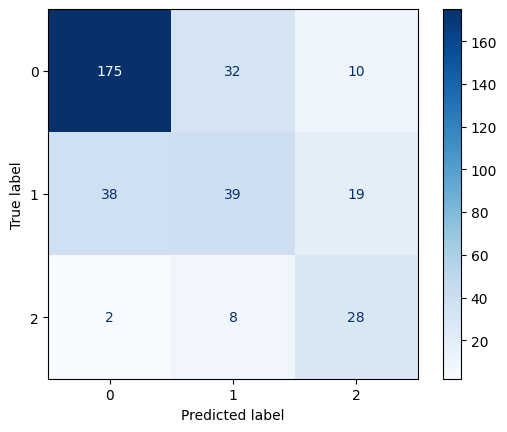

In [281]:
import numpy as np
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.metrics import make_scorer, confusion_matrix
import pandas as pd
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


from sklearn.metrics import make_scorer, confusion_matrix

rf_stage1 = RandomForestClassifier(class_weight={0: 1, 1: 2}, random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5]
}

cv1 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# gs_stage1 = GridSearchCV(
#     estimator=rf_stage1,
#     param_grid=param_grid,
#     cv=cv1,
#     scoring="f1",          # binary f1 for stage-1
#     n_jobs=-1,
#     verbose=1
# )
from sklearn.metrics import make_scorer, confusion_matrix

def cost_score(y_true, y_pred, fn_cost=5, fp_cost=1):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
    cost = fn_cost*fn + fp_cost*fp
    return -cost  # GridSearchCV maximizes

stage1_cost_scorer = make_scorer(cost_score, greater_is_better=True, fn_cost=6, fp_cost=1)

gs_stage1 = GridSearchCV(
    rf_stage1,
    param_grid=param_grid,
    cv=cv1,
    scoring=stage1_cost_scorer,
    n_jobs=-1,
    verbose=1
)
y_train_s1 = (y_train != 0).astype(int)  # 0 -> 0, 1/2 -> 1
y_test_s1  = (y_test  != 0).astype(int)

# Fit stage-1
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 Best Params:", gs_stage1.best_params_)
gs_stage1.fit(X_train, y_train_s1)
best_stage1 = gs_stage1.best_estimator_
print("Stage-1 best params (LinearSVC):", gs_stage1.best_params_)

svm_pipe1 = Pipeline([
    ("scaler", StandardScaler(with_mean=False) if hasattr(X_train, "sparse") else StandardScaler()),
    ("clf", LinearSVC(class_weight="balanced", random_state=42,dual=False))
])

param_grid_svm = {
    "clf__C": [0.01, 0.1, 1, 10]
}

gs_stage2 = GridSearchCV(
    svm_pipe1, param_grid_svm,
    cv=cv1,
    n_jobs=-1,
    verbose=1
)


# ---------------------------------------------------
# 3) Stage-2 training set: only samples with {1,2}
# ---------------------------------------------------
import pandas as pd

# Convert y to pandas Series with same index as X
y_train = pd.Series(y_train, index=X_train.index)
y_test  = pd.Series(y_test,  index=X_test.index)

# Now this works safely
mask_train_12 = y_train != 0
X_train_12 = X_train.loc[mask_train_12]
y_train_12 = y_train.loc[mask_train_12]
 

# Map {1,2} -> {0,1} for stage-2
y_train_s2 = (y_train_12 == 2).astype(int)  # 1 -> 0, 2 -> 1

# Fit stage-2
gs_stage2.fit(X_train_12, y_train_s2)
best_stage2 = gs_stage2.best_estimator_
print("Stage-2 Best Params:", gs_stage2.best_params_)

# Calibrate Stage 2 model for probability output and consistent predictions
# CalibratedClassifierCV wraps LinearSVC to provide predict_proba
from sklearn.calibration import CalibratedClassifierCV
print("\nCalibrating Stage 2 model...")
calibrated_stage2 = CalibratedClassifierCV(best_stage2, method='sigmoid', cv=5)
calibrated_stage2.fit(X_train_12, y_train_s2)
print("Calibration complete.")

# ---------------------------------------
# 4) Two-stage inference on the test set
# ---------------------------------------
# Stage-1 prediction: 0 vs (1/2)
pred_s1 = best_stage1.predict(X_test)  # 0 or 1

# Initialize final preds as 0
y_pred_two_stage = np.zeros_like(y_test)

# For samples predicted as (1/2), run stage-2
idx_12 = np.where(pred_s1 == 1)[0]
if len(idx_12) > 0:
    pred_s2 = calibrated_stage2.predict(X_test.iloc[idx_12])  # 0->class1, 1->class2
    y_pred_two_stage[idx_12] = np.where(pred_s2 == 0, 1, 2)

# -------------------------
# 5) Evaluation (3-class)
# -------------------------
print("\n=== Two-Stage Classification Report (3-class) ===")
print(classification_report(y_test, y_pred_two_stage, digits=4))

cm = confusion_matrix(y_test, y_pred_two_stage, labels=[0,1,2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0,1,2])
disp.plot(cmap="Blues")

# -------------------------
# 6) Optional: Stage-wise reports
# -------------------------
print("\n=== Stage-1 Report (0 vs {1,2}) ===")
print(classification_report(y_test_s1, pred_s1, digits=4))

# Evaluate stage-2 only where true label is in {1,2}
# 
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# mask of samples routed to stage-2 (stage-1 predicted {1,2})
mask_routed = (pred_s1 == 1)

# Subset X and y for only routed samples
X_routed = X_test.loc[mask_routed]
y_routed_true = y_test.loc[mask_routed]   # ground truth on routed samples

print("Routed samples count:", len(X_routed))
print("Routed true label distribution:\n", y_routed_true.value_counts().sort_index())

# Stage-2 predictions on routed samples
pred_s2_routed = calibrated_stage2.predict(X_routed)  # 0/1 (meaning class1/class2)

# For stage-2 metrics, keep ONLY cases where ground truth is 1 or 2
mask_true_12 = y_routed_true.isin([1, 2])
y_true_12 = y_routed_true.loc[mask_true_12]

# Map y_true {1,2} -> {0,1} to match stage-2 outputs
y_true_s2 = (y_true_12 == 2).astype(int)

pred_s2_eval = pred_s2_routed[mask_true_12.to_numpy()]  # align with filtered y_true_12

print("\n=== Stage-2 Report (pipeline-routed subset, true in {1,2}) ===")
print(classification_report(y_true_s2, pred_s2_eval, digits=4))
print("Confusion matrix (rows=true [1,2]=>[0,1], cols=pred [0,1]):")
print(confusion_matrix(y_true_s2, pred_s2_eval))




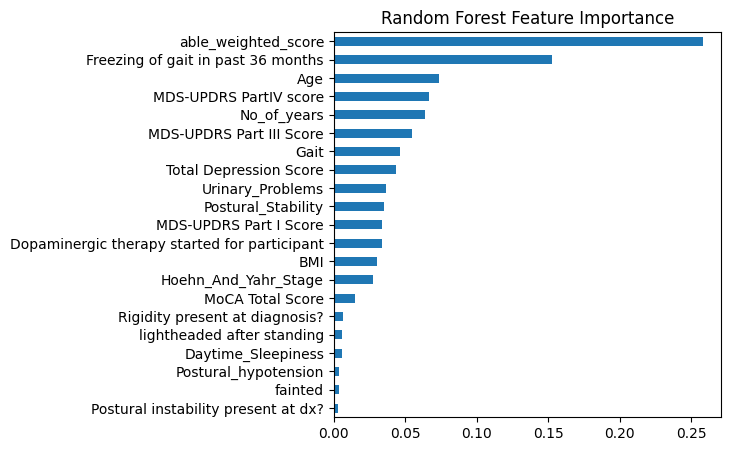

In [282]:
import matplotlib.pyplot as plt

rf_importances = pd.Series(best_stage1.feature_importances_, index=X_train.columns).sort_values(ascending=True)
rf_importances.plot(kind='barh', figsize=(5,5))
plt.title('Random Forest Feature Importance')
plt.show()


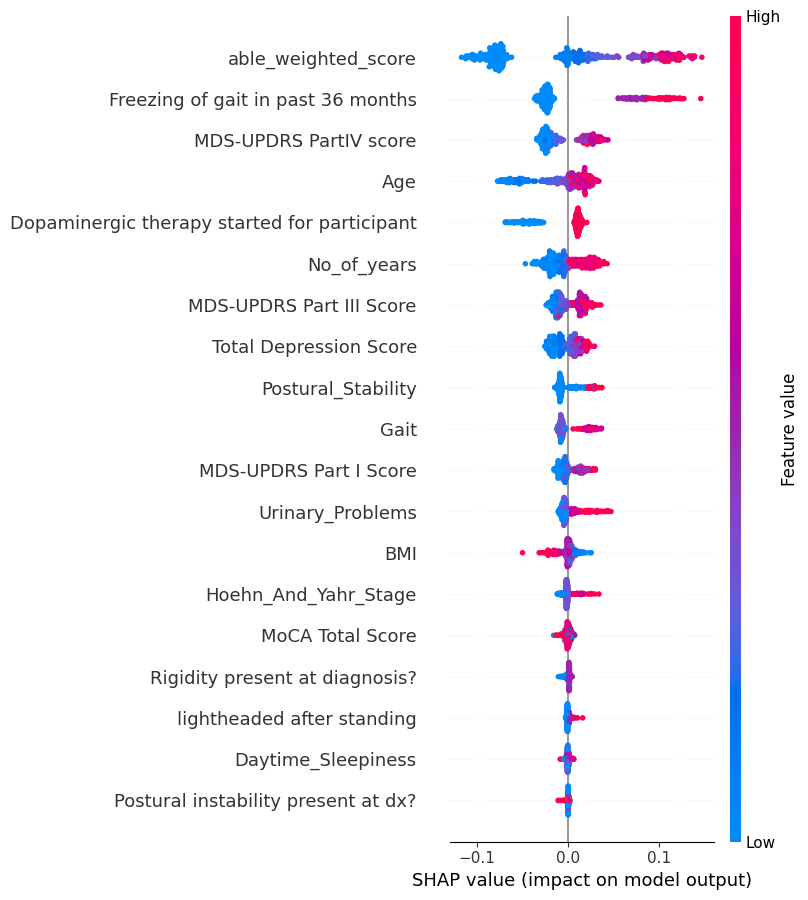

In [283]:
# Compute SHAP values
import shap
explainer = shap.Explainer(best_stage1, X_train)
shap_values = explainer(X_test)
# Select SHAP values for class 1 (any-fall)
shap_vals_stage1 = shap_values.values[:, :, 1]

# Beeswarm plot (all 19 features)
shap.summary_plot(
    shap_vals_stage1,
    X_test,
    plot_type="dot",     # beeswarm
    max_display=19
)

In [ ]:
# Stage 1 Artifacts generation for Explanation Layer (calculate SHAP values, predictions)
# explanation_artifacts/X_test.csv - patient feature values for the test set
# explanation_artifacts/shap_values_stage1.npy - SHAP values for stage-1 predictions on the test set
# explanation_artifacts/y_pred_proba.npy - predicted probabilities for class 1 (fall)
# explanation_artifacts/patient_ids_test.csv - stable patient identifiers aligned row-for-row with X_test/SHAP/predictions
import numpy as np
from pathlib import Path

artifacts_dir = Path('explanation_artifacts')
artifacts_dir.mkdir(exist_ok=True)

np.save(artifacts_dir / 'shap_values_stage1.npy', shap_vals_stage1)
X_test.to_csv(artifacts_dir / 'X_test.csv', index=False) 
id_test.to_csv(artifacts_dir / 'patient_ids_test.csv', index=False)

# Save predicted probabilities for class 1 (any fall)
y_pred_proba = best_stage1.predict_proba(X_test)[:, 1]
np.save(artifacts_dir / 'y_pred_proba.npy', y_pred_proba)

print(f"Saved artifacts directory: {artifacts_dir.resolve()}")
print(f"Saved SHAP values shape: {shap_vals_stage1.shape}")
print(f"Saved X_test shape: {X_test.shape}")
print(f"Saved patient_ids_test shape: {id_test.shape}")
print(f"Saved predictions shape: {y_pred_proba.shape}")

Saved artifacts directory: /Users/sowjanyapadala/Desktop/Coursework/PD_project/Mobility_Decline_Risk_Prediction_For_PD_Patients/explanation_artifacts
Saved SHAP values shape: (351, 21)
Saved X_test shape: (351, 21)
Saved patient_ids_test shape: (351,)
Saved predictions shape: (351,)


In [ ]:
# Stage 2 Artifact Generation for Explanation Layer
# Stage 2 explains severity (mild vs moderate falls) for patients predicted 
# to have "any fall" by Stage 1.
#
# The calibrated model was created by wrapping LinearSVC (best_stage2) 
# with CalibratedClassifierCV to enable
# probability estimates required by KernelExplainer.

import shap

# 1. Create routing mask: which test patients were routed to Stage 2
routing_mask = (pred_s1 == 1)  # True for patients predicted as "any fall"
print(f"Routing mask shape: {routing_mask.shape}")
print(f"Patients routed to Stage 2: {routing_mask.sum()} / {len(routing_mask)}")

# 2. Stage 2 predictions for routed patients (using calibrated model for consistency)
X_routed = X_test.iloc[routing_mask.to_numpy() if hasattr(routing_mask, 'to_numpy') else routing_mask]
y_pred_proba_s2 = calibrated_stage2.predict_proba(X_routed)[:, 1]  # P(moderate falls)
y_pred_s2 = calibrated_stage2.predict(X_routed)  # 0=mild, 1=moderate
print(f"\nStage 2 predictions shape: {y_pred_s2.shape}")
print(f"Stage 2 probabilities shape: {y_pred_proba_s2.shape}")

# 3. Compute SHAP values for Stage 2
# KernelExplainer uses the same calibrated model to ensure explanations match predictions
print("\nComputing Stage 2 SHAP values (this may take a moment)...")
background_s2 = shap.sample(X_train_12, 100, random_state=42)
explainer_s2 = shap.KernelExplainer(calibrated_stage2.predict_proba, background_s2)
shap_values_s2 = explainer_s2.shap_values(X_routed)

# SHAP returns list [class0, class1] (old API) or 3D array (new API); we want class 1 (moderate falls)
if isinstance(shap_values_s2, list):
    shap_vals_stage2 = shap_values_s2[1]
elif shap_values_s2.ndim == 3:
    shap_vals_stage2 = shap_values_s2[:, :, 1]  # New SHAP API: (N, features, classes)
else:
    shap_vals_stage2 = shap_values_s2

print(f"Stage 2 SHAP values shape: {shap_vals_stage2.shape}")

# 4. Rebuild y_pred_final from calibrated model to ensure consistency
# This ensures the saved predictions match exactly what the calibrated model predicts
y_pred_final = np.zeros(len(X_test), dtype=np.int64)
routed_indices = np.where(routing_mask)[0]
y_pred_final[routed_indices] = np.where(y_pred_s2 == 0, 1, 2)  # 0→1(mild), 1→2(moderate)

# 5. Save all Stage 2 artifacts
np.save(artifacts_dir / 'routing_mask.npy', routing_mask)
np.save(artifacts_dir / 'shap_values_stage2.npy', shap_vals_stage2)
np.save(artifacts_dir / 'y_pred_proba_s2.npy', y_pred_proba_s2)
np.save(artifacts_dir / 'y_pred_s2.npy', y_pred_s2)
np.save(artifacts_dir / 'y_pred_final.npy', y_pred_final)

print("\n" + "="*60)
print("Stage 2 artifacts saved:")
print(f"  routing_mask.npy          : {routing_mask.shape} bool")
print(f"  shap_values_stage2.npy    : {shap_vals_stage2.shape}")
print(f"  y_pred_proba_s2.npy       : {y_pred_proba_s2.shape}")
print(f"  y_pred_s2.npy             : {y_pred_s2.shape}")
print(f"  y_pred_final.npy          : {y_pred_final.shape} (3-class)")
print("="*60)

In [ ]:

# Verification: Consistent Stage 2 Model Usage
# This cell verifies that y_pred_final is correctly derived from calibrated_stage2
# predictions, ensuring SHAP explanations match displayed predictions.

def verify_stage2_consistency():
    """Verify that Stage 2 artifacts are internally consistent."""
    import numpy as np
    from pathlib import Path
    
    artifacts_dir = Path('explanation_artifacts')
    
    # Load artifacts
    routing_mask = np.load(artifacts_dir / 'routing_mask.npy')
    y_pred_s2 = np.load(artifacts_dir / 'y_pred_s2.npy')
    y_pred_final = np.load(artifacts_dir / 'y_pred_final.npy')
    
    # Test 1: y_pred_final for routed patients should match y_pred_s2 mapping
    routed_indices = np.where(routing_mask)[0]
    expected_final = np.where(y_pred_s2 == 0, 1, 2)  # 0→1(mild), 1→2(moderate)
    actual_final = y_pred_final[routed_indices].astype(int)
    
    mismatches = (expected_final != actual_final).sum()
    assert mismatches == 0, f"FAIL: {mismatches} mismatches between y_pred_s2 and y_pred_final"
    print(f"✓ Test 1 passed: y_pred_final matches y_pred_s2 for all {len(routed_indices)} routed patients")
    
    # Test 2: Non-routed patients should have prediction 0 (no fall)
    non_routed_indices = np.where(~routing_mask)[0]
    non_routed_preds = y_pred_final[non_routed_indices]
    assert (non_routed_preds == 0).all(), "FAIL: Non-routed patients should have prediction 0"
    print(f"✓ Test 2 passed: All {len(non_routed_indices)} non-routed patients have prediction 0")
    
    # Test 3: y_pred_s2 should only contain 0 or 1
    assert set(np.unique(y_pred_s2)).issubset({0, 1}), "FAIL: y_pred_s2 should only contain 0 or 1"
    print(f"✓ Test 3 passed: y_pred_s2 contains only valid values (0=mild, 1=moderate)")
    
    # Test 4: y_pred_final should only contain 0, 1, or 2
    assert set(np.unique(y_pred_final)).issubset({0, 1, 2}), "FAIL: y_pred_final should only contain 0, 1, or 2"
    print(f"✓ Test 4 passed: y_pred_final contains only valid 3-class values")
    
    # Summary stats
    print(f"\nSummary:")
    print(f"  Total patients: {len(y_pred_final)}")
    print(f"  Routed to Stage 2: {routing_mask.sum()}")
    print(f"  Stage 2 predictions: {(y_pred_s2 == 0).sum()} mild, {(y_pred_s2 == 1).sum()} moderate")
    print(f"  Final predictions: {(y_pred_final == 0).sum()} no-fall, {(y_pred_final == 1).sum()} mild, {(y_pred_final == 2).sum()} moderate")
    
    print("\n" + "="*60)
    print("All consistency checks passed!")
    print("="*60)

verify_stage2_consistency()


In [287]:
import numpy as np
import pandas as pd
from pathlib import Path

artifacts_dir = Path("explanation_artifacts")
shap_values = np.load(artifacts_dir / "shap_values_stage1.npy")
y_pred_proba = np.load(artifacts_dir / "y_pred_proba.npy")
X_test = pd.read_csv(artifacts_dir / "X_test.csv")

for i in range(5):
    print("=" * 80)
    print(f"Row index: {i}")
    print(f"Predicted probability of any fall: {y_pred_proba[i]:.4f}")
    
    patient_shap = pd.Series(shap_values[i], index=X_test.columns)
    
    print("\nTop 5 positive SHAP features:")
    print(patient_shap.sort_values(ascending=False).head(5))
    
    print("\nTop 5 negative SHAP features:")
    print(patient_shap.sort_values(ascending=True).head(5))
    
    print("\nPatient feature values:")
    print(X_test.iloc[i])
    print()

Row index: 0
Predicted probability of any fall: 0.4037

Top 5 positive SHAP features:
Age                                             0.024826
Dopaminergic therapy started for participant    0.011106
BMI                                             0.006789
MoCA Total Score                                0.001092
Postural_hypotension                            0.000191
dtype: float64

Top 5 negative SHAP features:
MDS-UPDRS PartIV score               -0.030259
Freezing of gait in past 36 months   -0.023708
Total Depression Score               -0.023486
MDS-UPDRS Part I Score               -0.014855
MDS-UPDRS Part III Score             -0.011256
dtype: float64

Patient feature values:
No_of_years                                      5.000000
Age                                             79.000000
Postural instability present at dx?              0.000000
Rigidity present at diagnosis?                   0.000000
Dopaminergic therapy started for participant     1.000000
MoCA Total Score  